In [1]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Para resultados deterministas (más lento pero reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False





In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random




# ============================================================
# 1. Sampler of private costs (Uniform[0,1])
# ============================================================
class BaselineSampler:
    def __init__(self, n_players):
        self.n_players = n_players

    def sample(self, batch_size):
        c = torch.rand(batch_size, self.n_players, 1)   # costs
        o = c                                           # observations
        return c, o



# ============================================================
# 2. BidderNet — SeLU hidden layers + ReLU output
#     Guarantees: bid >= cost  (important for reverse auctions)
# ============================================================
class BidderNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 10),
            nn.SELU(),
            nn.Linear(10, 10),
            nn.SELU(),
            nn.Linear(10, 1)    # raw output → processed in forward()
        )

    def forward(self, x):
        # markup >= 0
        markup = torch.relu(self.layers(x))
        # bid = cost + markup
        return x + markup



# ============================================================
# 3. PRETRAIN — pushes bids close to truthful strategy: bid = cost
# ============================================================
def pretrain_truthful(policies, sampler, device, steps=500, batch_size=2**17):
    optims = [torch.optim.SGD(pol.parameters(), lr=0.01) for pol in policies]

    print("\n>>> Pretraining truthful bidding (bid = cost)...\n")
    for step in range(steps):
        costs, obs = sampler.sample(batch_size)
        costs, obs = costs.to(device), obs.to(device)

        for i, pol in enumerate(policies):
            optims[i].zero_grad()

            pred = pol(obs[:, i])
            target = costs[:, i]

            loss = ((pred.squeeze() - target.squeeze()) ** 2).mean()

            loss.backward()
            optims[i].step()

        if step % 100 == 0:
            print(f"Pretrain step {step}/500 — loss={loss.item():.6f}")



# ============================================================
# 4. TRAINING NPGA WITH ES + ADAM (reverse auction)
# ============================================================
def train_npga_full(
    n_players=3,
    n_epochs=1000,
    pretrain_iters=500,
    batch_size=2**17,
    pop=64,
    lr=0.03,
    eval_frequency=200,
    n_runs=1,
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\n>>> Running on device:", device)

    sampler = BaselineSampler(n_players)
    all_results = []

    for run in range(n_runs):
        seed = 1000 + run
        set_seed(seed)
        print(f"\n==============================")
        print(f"     RUN {run+1}/{n_runs}")
        print(f"==============================\n")

        # Create policies
        policies = [BidderNet().to(device) for _ in range(n_players)]
        optims = [torch.optim.Adam(pol.parameters(), lr=lr) for pol in policies]

        grid = torch.linspace(0, 1, 200).view(200, 1).to(device)

        # -------------------------------
        # PRETRAIN: bid ≈ cost
        # -------------------------------
        pretrain_truthful(policies, sampler, device)

        results = {"epoch": [], "mse": [], "curves": []}

        # ============================================================
        # MAIN TRAINING LOOP
        # ============================================================
        for epoch in range(n_epochs):

            c_batch, o_batch = sampler.sample(batch_size)
            c_batch, o_batch = c_batch.to(device), o_batch.to(device)

            # ------------------------------
            # BASELINES PER PLAYER
            # ------------------------------
            baselines = []
            with torch.no_grad():
                bids = torch.cat([pol(o_batch[:, i])
                                  for i, pol in enumerate(policies)], dim=1)

                winners = torch.argmin(bids, dim=1)

                for i in range(n_players):
                    util_i = (winners == i) * (bids[:, i].squeeze() - c_batch[:, i].squeeze())
                    baselines.append(util_i.mean())

           # =======================================================
            # ES UPDATE (two-sided, antithetic)
            # =======================================================
            for i in range(n_players):

                theta = list(policies[i].parameters())
                theta_vec = torch.cat([p.data.flatten() for p in theta])
                d = theta_vec.numel()
                sigma = 0.05  # prueba algo fijo y razonable

                grad_vec = torch.zeros_like(theta_vec, device=device)

                # P perturbaciones simétricas
                for k in range(pop):
                    eps = torch.randn(d, device=device)

                    # θ+ and θ-
                    theta_plus  = theta_vec + sigma * eps
                    theta_minus = theta_vec - sigma * eps

                    # una red temporal para evaluar la política perturbada
                    pert = BidderNet().to(device)

                    # ---- u(θ + σ ε) ----
                    offset = 0
                    for p in pert.parameters():
                        size = p.numel()
                        p.data = theta_plus[offset:offset+size].view_as(p)
                        offset += size

                    with torch.no_grad():
                        all_bids = []
                        for j in range(n_players):
                            if j == i:
                                all_bids.append(pert(o_batch[:, j]))
                            else:
                                all_bids.append(policies[j](o_batch[:, j]))
                        all_bids = torch.cat(all_bids, dim=1)
                        winners = torch.argmin(all_bids, dim=1)
                        bid_i_plus = pert(o_batch[:, i]).squeeze()
                        util_i_plus = (winners == i) * (bid_i_plus - c_batch[:, i].squeeze())
                        u_plus = util_i_plus.mean()

                    # ---- u(θ - σ ε) ----
                    offset = 0
                    for p in pert.parameters():
                        size = p.numel()
                        p.data = theta_minus[offset:offset+size].view_as(p)
                        offset += size

                    with torch.no_grad():
                        all_bids = []
                        for j in range(n_players):
                            if j == i:
                                all_bids.append(pert(o_batch[:, j]))
                            else:
                                all_bids.append(policies[j](o_batch[:, j]))
                        all_bids = torch.cat(all_bids, dim=1)
                        winners = torch.argmin(all_bids, dim=1)
                        bid_i_minus = pert(o_batch[:, i]).squeeze()
                        util_i_minus = (winners == i) * (bid_i_minus - c_batch[:, i].squeeze())
                        u_minus = util_i_minus.mean()

                    # contribución al gradiente
                    grad_vec += (u_plus - u_minus) * eps

                # estimador final
                grad_vec /= (2 * pop * sigma)

                # ADAM update (ascent → grad negativo)
                optims[i].zero_grad()
                offset = 0
                for p in policies[i].parameters():
                    size = p.numel()
                    g = -grad_vec[offset:offset+size].view_as(p)
                    p.grad = g
                    offset += size
                optims[i].step()


            # ===============================
            # EVALUATION EVENT
            # ===============================
            if epoch % eval_frequency == 0 or epoch == n_epochs - 1:
                with torch.no_grad():
                    learned_curve = policies[0](grid).cpu().numpy().squeeze()
                    vals = grid.cpu().numpy().squeeze()

                    # Reverse auction BNE for n=3:
                    bne = (2/3) * vals + 1/3

                    mse = np.mean((learned_curve - bne)**2)

                results["epoch"].append(epoch)
                results["mse"].append(mse)
                results["curves"].append(learned_curve)

                print(f"[Epoch {epoch}] MSE = {mse:.6f}")

        all_results.append(results)

    print("\n>>> Training finished.")
    return all_results



# ============================================================
# 5. RUN
# ============================================================
if __name__ == "__main__":

    results = train_npga_full(
        n_players=3,
        n_epochs=1000,
        pretrain_iters=500,
        batch_size=2**17,
        pop=64,
        lr=0.03,
        eval_frequency=200,
        n_runs=10,
    )


>>> Running on device: cuda

     RUN 1/10


>>> Pretraining truthful bidding (bid = cost)...

Pretrain step 0/500 — loss=0.068391
Pretrain step 100/500 — loss=0.000008
Pretrain step 200/500 — loss=0.000001
Pretrain step 300/500 — loss=0.000000
Pretrain step 400/500 — loss=0.000000
[Epoch 0] MSE = 0.015494
[Epoch 200] MSE = 0.000282
[Epoch 400] MSE = 0.003203
[Epoch 600] MSE = 0.008427
[Epoch 800] MSE = 0.005746
[Epoch 999] MSE = 0.009065

     RUN 2/10


>>> Pretraining truthful bidding (bid = cost)...

Pretrain step 0/500 — loss=0.000007
Pretrain step 100/500 — loss=0.000000
Pretrain step 200/500 — loss=0.000000
Pretrain step 300/500 — loss=0.000000
Pretrain step 400/500 — loss=0.000000
[Epoch 0] MSE = 0.074461
[Epoch 200] MSE = 0.000384
[Epoch 400] MSE = 0.004510
[Epoch 600] MSE = 0.027888
[Epoch 800] MSE = 0.016408
[Epoch 999] MSE = 0.009279

     RUN 3/10


>>> Pretraining truthful bidding (bid = cost)...

Pretrain step 0/500 — loss=0.000000
Pretrain step 100/500 — loss=0.000000


In [5]:
results 

[{'epoch': [0, 200, 400, 600, 800, 999],
  'mse': [np.float32(0.015493843),
   np.float32(0.0002816552),
   np.float32(0.0032033247),
   np.float32(0.008427147),
   np.float32(0.0057457495),
   np.float32(0.009065161)],
  'curves': [array([0.27994305, 0.28464034, 0.28931707, 0.29399577, 0.2986765 ,
          0.30335906, 0.30804363, 0.31273016, 0.31741858, 0.322109  ,
          0.3268013 , 0.33149558, 0.33619177, 0.3408898 , 0.3455898 ,
          0.35029167, 0.35499543, 0.35970107, 0.3644086 , 0.36911803,
          0.3738293 , 0.3785424 , 0.38325742, 0.38797432, 0.39269292,
          0.39741346, 0.40213582, 0.40686005, 0.41158605, 0.4163139 ,
          0.42104355, 0.42577505, 0.43050826, 0.4352433 , 0.43998012,
          0.4447187 , 0.44945914, 0.45420128, 0.45894524, 0.4636909 ,
          0.4684384 , 0.47318763, 0.4779385 , 0.48269126, 0.4874457 ,
          0.4922018 , 0.4969597 , 0.50171924, 0.5064806 , 0.51124364,
          0.5160084 , 0.52077484, 0.525543  , 0.53031266, 0.53508425,


## Curva promedio sobre runs

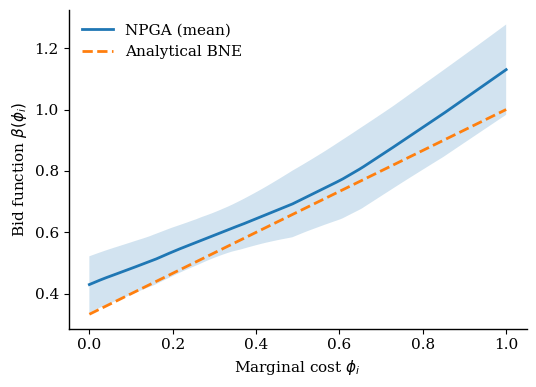

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- Estilo tipo paper ---
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "legend.frameon": False,
})

# Tomar la última curva de cada run
all_final_curves = np.array([r["curves"][-1] for r in results])

mean_curve = all_final_curves.mean(axis=0)
std_curve  = all_final_curves.std(axis=0)

vals = np.linspace(0, 1, 200)
bne = (2/3) * vals + (1/3)

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.plot(vals, mean_curve, lw=2, label=r"NPGA (mean)")
ax.fill_between(vals,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.2)

ax.plot(vals, bne, linestyle="--", lw=2,
        label=r"Analytical BNE")

ax.set_xlabel(r"Marginal cost $\phi_i$")
ax.set_ylabel(r"Bid function $\beta(\phi_i)$")

ax.legend()

plt.tight_layout()
plt.savefig("npga_vs_bne.png", bbox_inches="tight")
plt.show()

MSE promedio con bandas

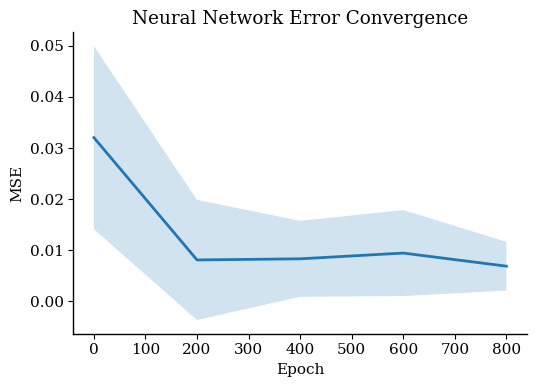

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- Estilo tipo paper ---
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "legend.frameon": False,
})

# Alinear epochs
epochs = results[0]["epoch"]

all_mse = np.array([r["mse"] for r in results])

mean_mse = all_mse.mean(axis=0)
std_mse  = all_mse.std(axis=0)

# Tomar solo los primeros 5 puntos
epochs_5   = epochs[:5]
mean_mse_5 = mean_mse[:5]
std_mse_5  = std_mse[:5]

fig, ax = plt.subplots(figsize=(5.5, 4))

# Línea principal
ax.plot(epochs_5, mean_mse_5, lw=2, label="NPGA MSE")

# Banda de ±std
ax.fill_between(epochs_5,
                mean_mse_5 - std_mse_5,
                mean_mse_5 + std_mse_5,
                alpha=0.2)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
plt.title("Neural Network Error Convergence")
plt.savefig("errorconvergence.png", bbox_inches="tight")
plt.tight_layout()
plt.show()